# Binary Classification with CNNs: pneumonia_MNIST Data Set

## Setup

In [ ]:
import tensorflow as tf
import datetime

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782456966.011065 1516277 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782456967.972618 1516277 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# load the dataset
import tensorflow_datasets as tfds

train_ds, validation_ds, test_ds = tfds.load(
    "pneumonia_mnist", split=["train", "val", "test"], as_supervised=True
)

batch_size = 32
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]


def make_callbacks(filepath):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_loss", mode="min"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


epochs = 10

# images are batched, so we need to extract them
y_true = tf.concat([y for x, y in test_ds], axis=0)

In [3]:
from visualization import summary_graphics


def get_class_training_weights(assignments, normalize=True):
    # inverse-frequency weighting: up-weight the MINORITY class
    n_total = len(assignments)
    n_pos = float(sum(assignments))  # number of class-1 (pneumonia) labels
    n_neg = n_total - n_pos  # number of class-0 (normal) labels
    weight_0 = n_total / (2 * n_neg)
    weight_1 = n_total / (2 * n_pos)
    if normalize:
        denom = max(weight_0, weight_1)
        weight_0 = weight_0 / denom
        weight_1 = weight_1 / denom
    return {0: weight_0, 1: weight_1}

In [4]:
class_weight = get_class_training_weights(tf.concat([y for x, y in train_ds], axis=0))

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.347


## Training

In [5]:
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1000, activation="relu", name="5.2dense"),
        tf.keras.layers.Dense(500, activation="relu", name="5.4dense"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_1.summary()

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 5.1flatten (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,001 (4.91 MB)

 Trainable params: 1,286,001 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adamw_1.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8426 - loss: 2.5001 - precision: 0.9396 - recall: 0.8420 - tn: 1025.0000 - tp: 2942.0000 - val_accuracy: 0.9466 - val_loss: 1.1050 - val_precision: 0.9688 - val_recall: 0.9589 - val_tn: 123.0000 - val_tp: 373.0000 - learning_rate: 1.0000e-04
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9036 - loss: 0.9539 - precision: 0.9651 - recall: 0.9027 - tn: 1100.0000 - tp: 3154.0000 - val_accuracy: 0.6489 - val_loss: 8.0180 - val_precision: 1.0000 - val_recall: 0.5270 - val_tn: 135.0000 - val_tp: 205.0000 - learning_rate: 1.0000e-04
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8753 - loss: 1.5151 - precision: 0.9549 - recall: 0.8732 - tn: 1070.0000 - tp: 3051.0000 - val_accuracy: 0.6947 - val_loss: 7.3912 - val_precision: 1.0000 - val_recall: 0.5887 - val_tn: 135.0000 - val_tp: 229.0000 - learning_rate: 1.0000e-04
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9146 - loss: 0.78

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


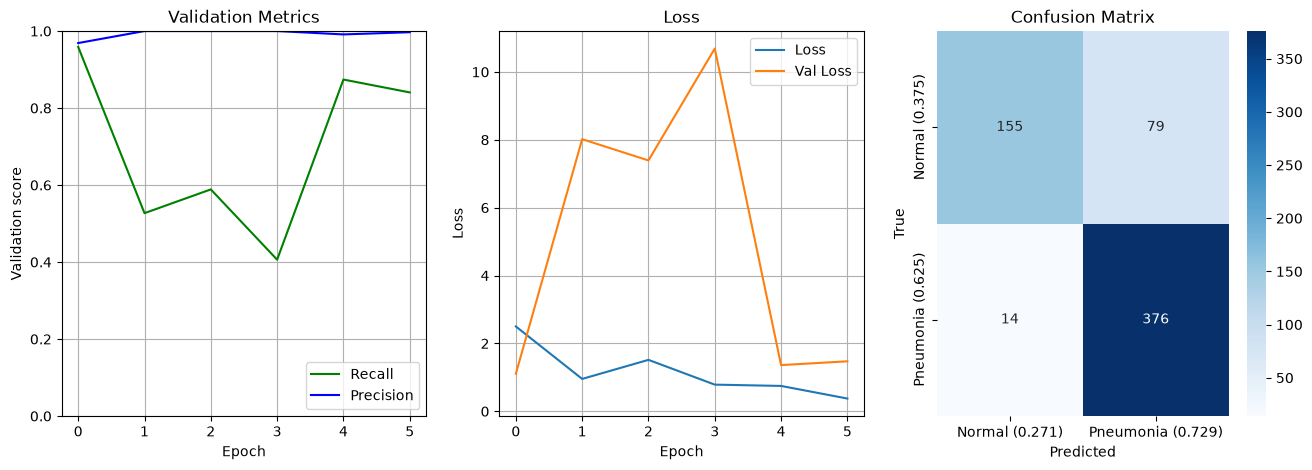

In [7]:
summary_graphics(history, model_1, test_ds)

In [8]:
# try something similar to xception, but with fewer filters and layers
# to account for how small these images are
model_2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_2",
)

model_2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_2.summary()

Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0.1rflip (RandomFlip)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 296,657 (1.13 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

In [9]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adamw_2.keras"),
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.7383 - loss: 0.3509 - precision: 0.8022 - recall: 0.8594 - tn: 526.0000 - tp: 3337.0000 - val_accuracy: 0.7424 - val_loss: 0.6840 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8297 - loss: 0.1941 - precision: 0.9487 - recall: 0.8145 - tn: 1060.0000 - tp: 2846.0000 - val_accuracy: 0.7538 - val_loss: 0.6655 - val_precision: 0.9962 - val_recall: 0.6710 - val_tn: 134.0000 - val_tp: 261.0000 - learning_rate: 1.0000e-04
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8492 - loss: 0.1683 - precision: 0.9555 - recall: 0.8357 - tn: 1078.0000 - tp: 2920.0000 - val_accuracy: 0.3779 - val_loss: 0.7215 - val_precision: 1.0000 - val_recall: 0.1620 - val_tn: 135.0000 - val_tp: 63.0000 - learning_rate: 1.0000e-04
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.8528 - loss: 0.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


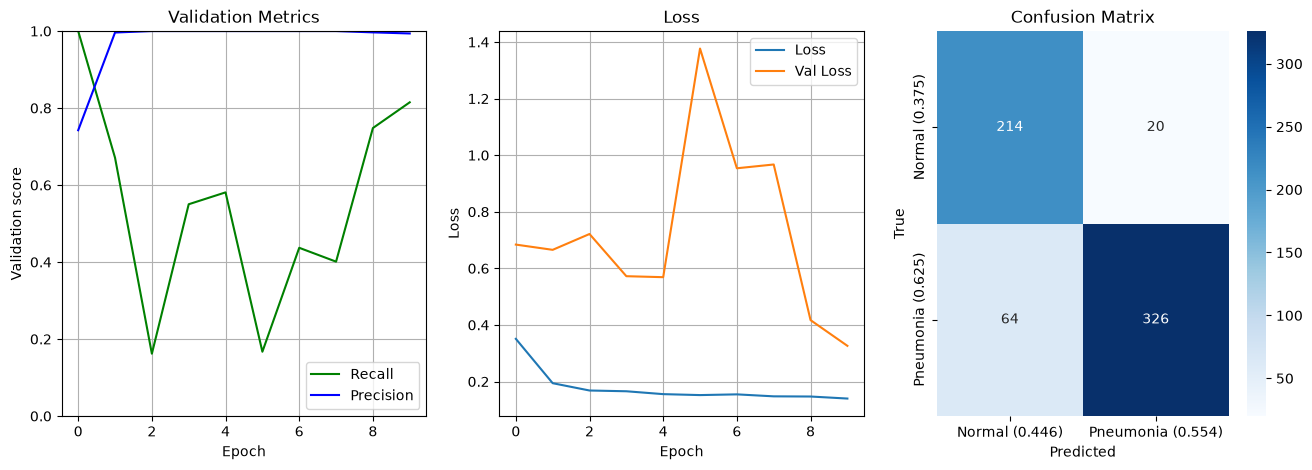

In [10]:
# validation accuracy and loss seem to be randomly crashing, so let's use the best model instead of just the last one
best_model = tf.keras.models.load_model("best_model_adamw_2.keras")
summary_graphics(history, best_model, test_ds)

In [11]:
# model accuracy seems to be capping out, so let's lower dropout slightly
model_3 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((28, 28, 1), name="input"),
        tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_3",
)

model_3.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

Epoch 1/10


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.6541 - loss: 0.3103 - precision: 0.9454 - recall: 0.5666 - tn: 1222.0000 - tp: 2200.0000 - val_accuracy: 0.7424 - val_loss: 0.6332 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8362 - loss: 0.1757 - precision: 0.9513 - recall: 0.8214 - tn: 1067.0000 - tp: 2870.0000 - val_accuracy: 0.7424 - val_loss: 0.5689 - val_precision: 0.7424 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8517 - loss: 0.1680 - precision: 0.9578 - recall: 0.8371 - tn: 1085.0000 - tp: 2925.0000 - val_accuracy: 0.7481 - val_loss: 0.5020 - val_precision: 0.7466 - val_recall: 1.0000 - val_tn: 3.0000 - val_tp: 389.0000 - learning_rate: 1.0000e-04
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8573 - loss: 0

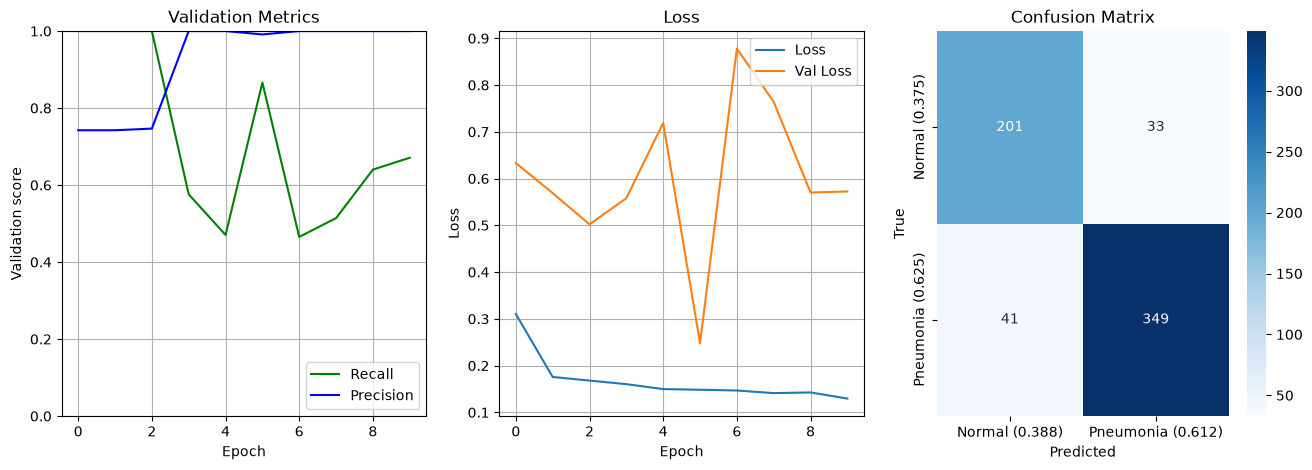

In [12]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adamw_3.keras"),
)
best_model = tf.keras.models.load_model("best_model_adamw_3.keras")
summary_graphics(history, best_model, test_ds)

In [ ]:
# maybe more epochs will help
epochs = 20
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks("best_model_adamw_3.keras"),
)
summary_graphics(history, model_3, test_ds)

Epoch 1/20


/home/sam/Documents/projects/ConvolutedComputerVision/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.8696 - loss: 0.1440 - precision: 0.9612 - recall: 0.8589 - tn: 1093.0000 - tp: 3001.0000 - val_accuracy: 0.5649 - val_loss: 0.9799 - val_precision: 1.0000 - val_recall: 0.4139 - val_tn: 135.0000 - val_tp: 161.0000 - learning_rate: 5.0000e-05
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8794 - loss: 0.1410 - precision: 0.9665 - recall: 0.8675 - tn: 1109.0000 - tp: 3031.0000 - val_accuracy: 0.6317 - val_loss: 0.8118 - val_precision: 1.0000 - val_recall: 0.5039 - val_tn: 135.0000 - val_tp: 196.0000 - learning_rate: 5.0000e-05
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8804 - loss: 0.1361 - precision: 0.9678 - recall: 0.8678 - tn: 1113.0000 - tp: 3032.0000 - val_accuracy: 0.8817 - val_loss: 0.2701 - val_precision: 0.9940 - val_recall: 0.8458 - val_tn: 133.0000 - val_tp: 329.0000 - learning_rate: 5.0000e-05
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8912 - loss: 0.13

In [ ]:
best_model = tf.keras.models.load_model("best_model_adamw_3.keras")
summary_graphics(history, best_model, test_ds)

In [ ]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)